In [1]:
import numpy as np
import math
from itertools import product
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

### Parameter Settings

In [ ]:
# Time step width
tau = 1
# Number of time steps
Total_steps = 200
# Time
T = Total_steps*tau
# Number of spatial grids
num_grid = 8
# Spatial step width
delta_x = 1
# Scale normalization coefficient
Lambda = 10**4
# Density
density = 1
# Permittivity
epsilon_0 = 1
# Mass
mass = 1
# Charge
q = -1
# Number of variables
N = 2*num_grid
# Upper limit of total particle number
m = 1
# Size of Hamiltonian matrix
M = math.comb(m+N, m)
# Number of x qubits
n_x = math.floor(np.log2(M))+1
# Number of ancilla qubits required for U
n_a = 1
eta=1
T_real=Total_steps*tau/(192*eta*(m/2)**(5/2))

k = 2*np.pi/num_grid
x_min = -num_grid/2
x_max = num_grid/2

Load QSVT Results

In [ ]:
# Load arrays from npy files
filename = 'output/CaseA/1DPlasmaOscillationTest_u_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(n_x, delta_x, T, tau, m)
u_qsvt = np.load(filename)
filename = 'output/CaseA/1DPlasmaOscillationTest_E_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(n_x, delta_x, T, tau, m)
E_qsvt = np.load(filename)

Load Classical Results

In [ ]:
# Load arrays from npy files
filename = 'output/CaseA/1DPlasmaOscillationTest_expm_u_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(n_x, delta_x, T, tau, m)
u_expm = np.load(filename)
filename = 'output/CaseA/1DPlasmaOscillationTest_expm_E_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.npy'.format(n_x, delta_x, T, tau, m)
E_expm = np.load(filename)

QSVT and Classical Results

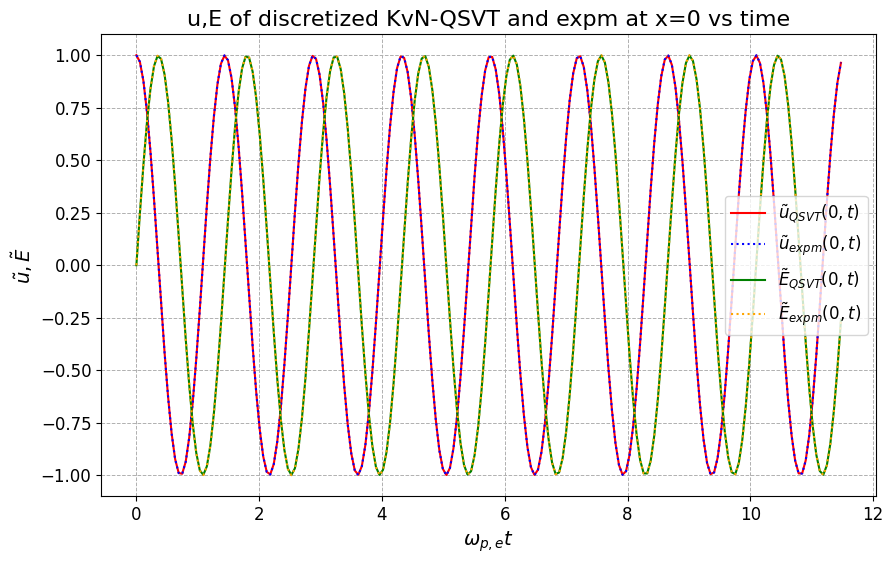

PDF plot for norm evolution in x and v space saved successfully.


In [5]:
t_min = 0
t_max = Total_steps/17.43
t = np.linspace(t_min, t_max, Total_steps+1)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t,u_qsvt[0,:], color="red", linestyle="-",label=r"$\tilde{u}_{QSVT}(0,t)$")
ax.plot(t,u_expm[0,:], color="blue", linestyle=":",label=r"$\tilde{u}_{expm}(0,t)$")
ax.plot(t,E_qsvt[0,:], color="green",linestyle="-", label=r"$\tilde{E}_{QSVT}(0,t)$")
ax.plot(t,E_expm[0,:], color="orange", linestyle=":", label=r"$\tilde{E}_{expm}(0,t)$")

# Add labels and title
ax.set_xlabel(r'$\omega_{p,e}t$', fontsize=14)
ax.set_ylabel(r'$\tilde{u},\tilde{E}$', fontsize=14)
ax.set_title('u,E of discretized KvN-QSVT and expm at x=0 vs time', fontsize=16)

# Customize the plot
tick_size = 12
ax.grid(True, linestyle='--', linewidth=0.7)
ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=tick_size)

# Save the plot as PDF
plt.savefig('output/CaseA/1DPlasmaOscillationTest_u_E_nx_{}_delta_x_{}_T_{}_delta_t_{}_m_{}.pdf'.format(n_x, delta_x, T, tau, m), format='pdf')

# Show the plot
plt.show()
plt.close(fig)

print("PDF plot for norm evolution in x and v space saved successfully.")